In [1]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

2023-06-07 15:33:52.915237: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load the data.

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [3]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 30.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

# Normalize the data. 
df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index) 

In [4]:
group_size = 10

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

In [5]:
antigen = list(df.index.get_level_values('Peptide'))
time = list(df.index.get_level_values('Time'))

In [6]:
X = np.array(df.values)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

# Setup the autoencoder model. 

In [7]:
autoencoder = Sequential([
    layers.Dense(15, activation='elu'),
    layers.Dense(10, activation='softsign'),
    layers.Dense(5, activation='swish'),
    layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
    layers.Dense(5, activation='selu'), 
    layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
])

In [8]:
autoencoder.compile(optimizer='adagrad', loss=losses.CategoricalCrossentropy(), metrics=['categorical_accuracy'])

In [9]:
CHECKPOINT_PATH = "training/train_2D/cp-{epoch:04d}.ckpt"
checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

BATCH_SIZE = 1024
STEPS_PER_EPOCH = X_train.shape[0] / BATCH_SIZE
SAVE_PERIOD = 10


training_callback = ModelCheckpoint(filepath=CHECKPOINT_PATH,
                                    save_weights_only=True,
                                    verbose=1, 
                                    save_freq=int(SAVE_PERIOD * STEPS_PER_EPOCH)
                                )

# autoencoder.save_weights(CHECKPOINT_PATH.format(epoch=0))

tf.random.set_seed(42)

hist = autoencoder.fit(X_train, y_train,
                epochs=1000,
                shuffle=True,
                validation_data=(X_test, y_test),
                callbacks=[training_callback],
                batch_size=BATCH_SIZE,
                verbose=0)


Epoch 10: saving model to training/train_2D/cp-0010.ckpt

Epoch 20: saving model to training/train_2D/cp-0020.ckpt

Epoch 30: saving model to training/train_2D/cp-0030.ckpt

Epoch 40: saving model to training/train_2D/cp-0040.ckpt

Epoch 50: saving model to training/train_2D/cp-0050.ckpt

Epoch 60: saving model to training/train_2D/cp-0060.ckpt

Epoch 70: saving model to training/train_2D/cp-0070.ckpt

Epoch 80: saving model to training/train_2D/cp-0080.ckpt

Epoch 90: saving model to training/train_2D/cp-0090.ckpt

Epoch 100: saving model to training/train_2D/cp-0100.ckpt

Epoch 110: saving model to training/train_2D/cp-0110.ckpt

Epoch 120: saving model to training/train_2D/cp-0120.ckpt

Epoch 130: saving model to training/train_2D/cp-0130.ckpt

Epoch 140: saving model to training/train_2D/cp-0140.ckpt

Epoch 150: saving model to training/train_2D/cp-0150.ckpt

Epoch 160: saving model to training/train_2D/cp-0160.ckpt

Epoch 170: saving model to training/train_2D/cp-0170.ckpt

Epoch

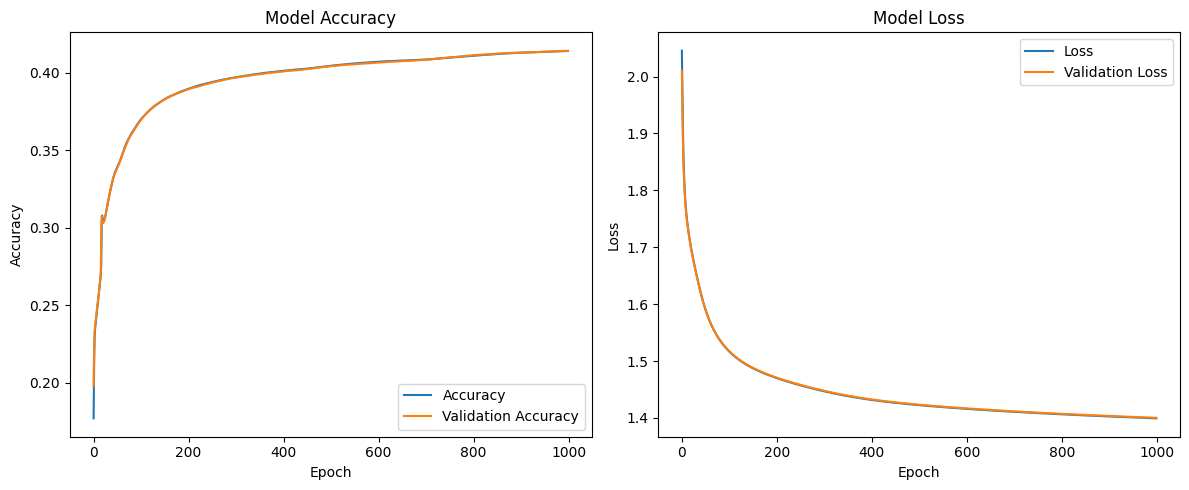

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the accuracy on the first subplot
ax1.plot(hist.history['categorical_accuracy'], label='Accuracy')
ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot the loss on the second subplot
ax2.plot(hist.history['loss'], label='Loss')
ax2.plot(hist.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Get the embedding from the bottleneck layer. 

In [11]:
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 15)                405       
                                                                 
 dense_1 (Dense)             (None, 10)                160       
                                                                 
 dense_2 (Dense)             (None, 5)                 55        
                                                                 
 Bottleneck (Dense)          (None, 2)                 12        
                                                                 
 dense_3 (Dense)             (None, 5)                 15        
                                                                 
 Output (Dense)              (None, 8)                 48        
                                                                 
Total params: 695
Trainable params: 695
Non-trainable pa

In [12]:
train_time, test_time = train_test_split(time, test_size=TEST_PROPORTION, random_state=42)
train_antigen, test_antigen = train_test_split(antigen, test_size=TEST_PROPORTION, random_state=42)

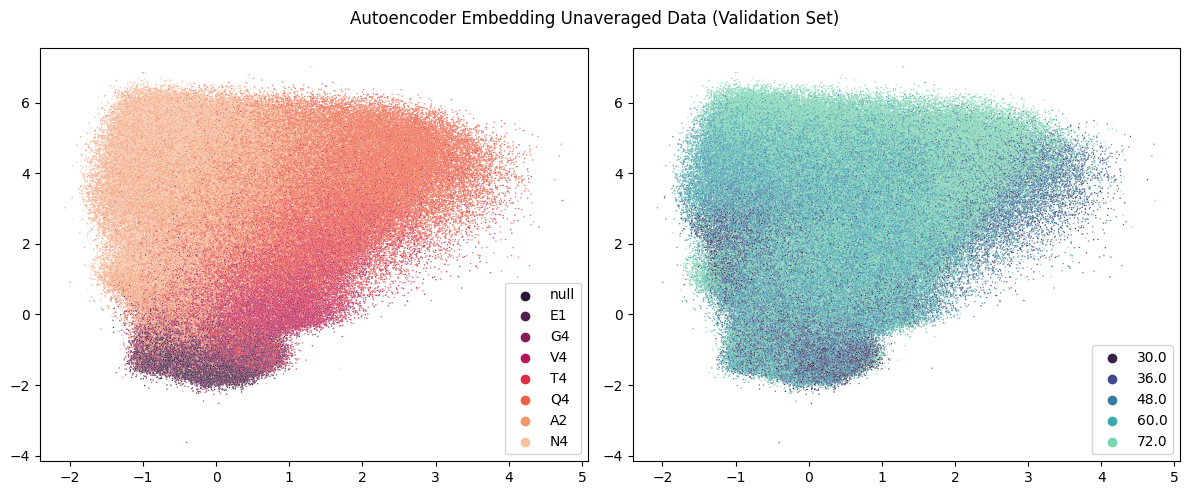

In [13]:
extractor = Model(inputs=autoencoder.inputs,
                        outputs=autoencoder.get_layer("Bottleneck").output)
embedding = np.array( extractor(X_test) )

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=1, 
    ax=ax1
)

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_time), 
    palette="mako", 
    s=1, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Unaveraged Data (Validation Set)")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()

# Now we can color the scatter plot by different values of markers. 

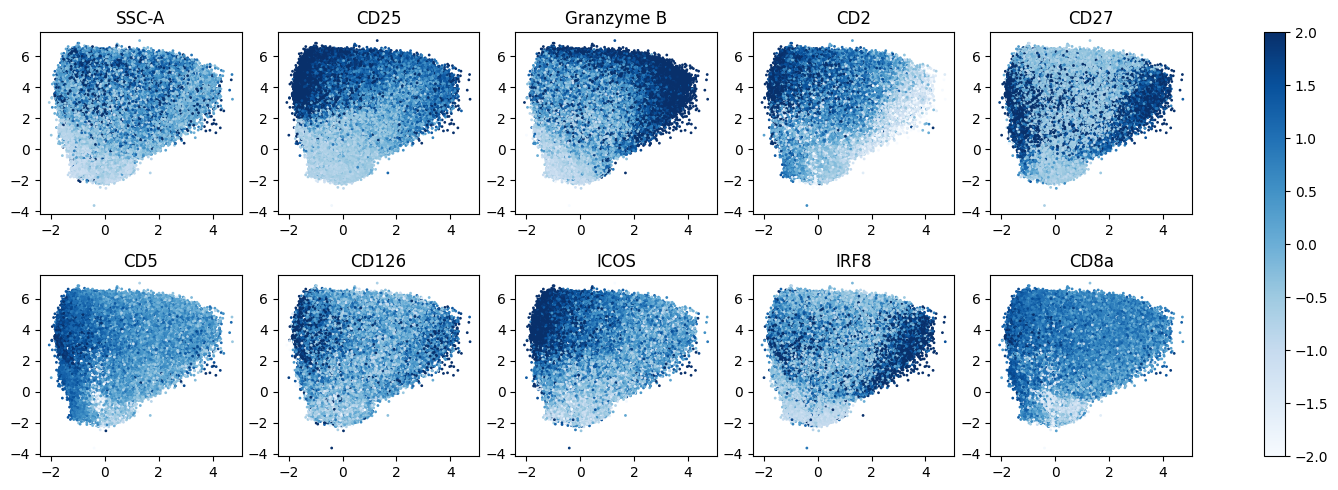

In [14]:
# Plot the top ten markers identified from before. 
MARKERS = ['SSC-A','CD25','Granzyme B','CD2','CD27','CD5','CD126','ICOS','IRF8','CD8a']

fig, axs = plt.subplots(2, 5, figsize=(15,5))

axs = axs.flatten()

vmin = -2 * np.std(df.values)
vmax = 2 * np.std(df.values)

for i, marker in enumerate(MARKERS):
    train_marker, test_marker = train_test_split(df[marker], test_size=TEST_PROPORTION, random_state=42)

    sc = axs[i].scatter(
        x=embedding[:,0], 
        y=embedding[:,1], 
        c=test_marker, 
        cmap='Blues', 
        s=1, 
        vmin=vmin,
        vmax=vmax
    )

    axs[i].set_title(marker)

plt.tight_layout()

# cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
plt.colorbar(sc, ax=axs.ravel().tolist())

# Now we create a confusion matrix. 

In [15]:
from sklearn.metrics import confusion_matrix

y_pred = np.argmax( autoencoder(X_test), axis=1 )
y_true = np.argmax(y_test, axis=1) 

cm = confusion_matrix(y_true, y_pred)

cm

array([[34892,  2944,  9317,  3103,   491,    28,   370,   721],
       [ 9659,  6884,  4584, 13021,   982,    29,   211,   802],
       [25119,  3080, 10334,  4253,  1023,    41,   790,  1120],
       [ 6424,  4881,  4671, 26316, 17388,  1483,   510,  3113],
       [ 3886,  2664,  4034, 18413, 34932, 16562,  1225,  7607],
       [ 2652,  1646,  2400,  6841, 16761, 55222,   570, 13165],
       [ 3513,   170,  4564,  2474,  8720,  9269,  4222, 50601],
       [ 3854,   302,  4655,  3798, 11388,  8026,  2482, 62159]])

[Text(0, 0.5, 'null'),
 Text(0, 1.5, 'E1'),
 Text(0, 2.5, 'G4'),
 Text(0, 3.5, 'V4'),
 Text(0, 4.5, 'T4'),
 Text(0, 5.5, 'Q4'),
 Text(0, 6.5, 'A2'),
 Text(0, 7.5, 'N4')]

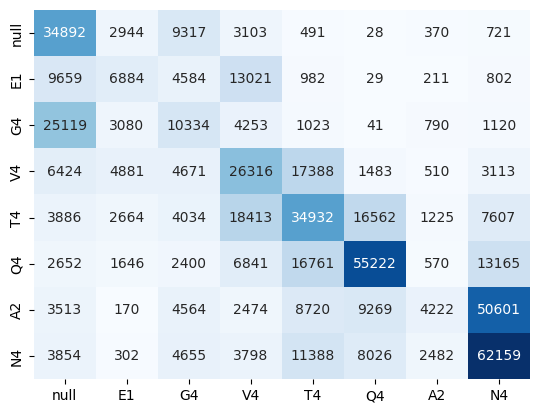

In [16]:
# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

# Set labels for the x and y axes
ax.set_xticklabels(ANTIGENS)
ax.set_yticklabels(ANTIGENS)